## Experiment results

In [ ]:
from pathlib import Path
import sys
import json
import os

IN_GITHUB = os.getenv("GITHUB_ACTIONS") == "true"
try:
    import google.colab

    IN_COLAB = True
    print("Running as a Colab notebook")
except:
  IN_COLAB = False
  print("Not running as a Colab notebook")

if IN_COLAB:
  %pip install transformer_lens
  from google.colab import drive
  drive.mount('/content/drive')
  ! pwd # Returns /content
  ! cp "/content/drive/MyDrive/Colab Notebooks/patching_algorithms_for_presentation.py" /content/patching_algorithms.py
  ! cp "/content/drive/MyDrive/Colab Notebooks/temporal_scope_for_attribution_patching_for_qwen3.json" /content/temporal_scope_for_attribution_patching.json
  import patching_algorithms

import plotly.express as px
import plotly.io as pio
import pandas as pd

Running as a Colab notebook
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content


### 1. Define the model of interest

In [ ]:
MODEL_NAME = "Qwen/Qwen3-4B"
#MODEL_NAME = "phi-3"

### 2. Read the dataset, prepare inputs for "short" circuits

In [ ]:
temporal_dataset = None
dataset_path = "temporal_scope_for_attribution_patching.json"
with open(dataset_path) as f:
    temporal_dataset = json.load(f)

clean_prompts = []
clean_answers = []
corrupted_prompts = []
corrupted_answers = []

for sample in temporal_dataset[1:]:
    clean_question = sample["corrupted"]["question"]
    clean_prompts.append(clean_question)
    clean_answers.append(sample["corrupted"]["answer"])

    corrupted_question = sample["clean"]["question"]
    corrupted_prompts.append(corrupted_question)
    corrupted_answers.append(sample["clean"]["answer"])


In [ ]:
from transformer_lens import (
    HookedTransformer,
    ActivationCache,
    patching
)

model_name = MODEL_NAME

model = HookedTransformer.from_pretrained(model_name)
model.set_use_attn_result(True)
is_qwen = False
if "Qwen" in model_name:
    model.set_use_split_qkv_input(True)
    is_qwen = True
else:
    model.set_use_attn_in(True)
model.set_use_hook_mlp_in(False)


clean_tokens = model.to_tokens(clean_prompts, prepend_bos=True, padding_side='left')
for i in range(len(clean_prompts)):
  string_tokens = [f"{i}, {model.to_string(t)}" for i, t in enumerate(clean_tokens[i])]
  print(string_tokens)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen3-4B into HookedTransformer
['0, <|im_end|>', '1, The', '2,  goal', '3,  is', '4,  to', '5,  make', '6,  a', '7,  gener', '8, ational', '9,  impact', '10, .', '11,  Is', '12,  this', '13,  a', '14,  short', '15, -term', '16,  or', '17,  long', '18, -term', '19,  goal', '20, ?', '21,  The', '22,  answer', '23,  is', '24, :']
['0, <|im_end|>', '1, The', '2,  goal', '3,  is', '4,  to', '5,  master', '6,  the', '7,  quantum', '8,  mechanics', '9,  fully', '10, .', '11,  Is', '12,  this', '13,  a', '14,  short', '15, -term', '16,  or', '17,  long', '18, -term', '19,  goal', '20, ?', '21,  The', '22,  answer', '23,  is', '24, :']
['0, <|im_end|>', '1, The', '2,  goal', '3,  is', '4,  to', '5,  set', '6,  Olympic', '7,  records', '8,  in', '9,  running', '10, .', '11,  Is', '12,  this', '13,  a', '14,  short', '15, -term', '16,  or', '17,  long', '18, -term', '19,  goal', '20, ?', '21,  The', '22,  answer', '23,  is', '24, :']
['0, <|im_end|>', '1, The', '2,  

### Run Activation patching function

In [ ]:
class ExperimentResult:
  def __init__(self, name, metric_name, technique_name, layers_pos_scores):
    self.name = name
    self.metric_name = metric_name
    self.technique_name = technique_name
    self.layers_pos_scores = layers_pos_scores.copy()
    self.layers_scores_avg = self.layers_pos_scores.mean(axis=1)

def run_full_activation_patching_experiment(model_name, clean_prompts, clean_answers, corrupted_prompts, corrupted_answers):
  techniques_to_run = [("Denoising", patching_algorithms.ActivationPatching.Technique.DENOISING),
                       ("Denoising_Both_Logprobs", patching_algorithms.ActivationPatching.Technique.DENOISING_BOTH_LOGPROBS),
                       ("Denoising_Custom", patching_algorithms.ActivationPatching.Technique.DENOISING_CUSTOM),
                       ("Denoising_Both_Logprobs_Custom", patching_algorithms.ActivationPatching.Technique.DENOISING_BOTH_LOGPROBS_CUSTOM),
                       ("Noising", patching_algorithms.ActivationPatching.Technique.NOISING),
                       ("Noising_Both_Logprobs", patching_algorithms.ActivationPatching.Technique.NOISING_BOTH_LOGPROBS),
                       ("Noising_Custom", patching_algorithms.ActivationPatching.Technique.NOISING_CUSTOM),
                       ("Noising_Both_Logprobs_Custom", patching_algorithms.ActivationPatching.Technique.NOISING_BOTH_LOGPROBS_CUSTOM)]
  metrics_to_run = [("logit_diff", patching_algorithms.ActivationPatching.Metric.LOGIT_DIFF)]
  residual_results = []
  attn_out_results = []
  mlp_out_results = []
  for technique_name, technique_type in techniques_to_run:
      for metric_name, metric_type in metrics_to_run:
          print(f"\n\n\nRunning experiment for technique: {technique_name}, metric: {metric_name}!")
          act_patch = patching_algorithms.ActivationPatching(MODEL_NAME,
                                                            clean_prompts, clean_answers,
                                                            corrupted_prompts, corrupted_answers,
                                                            metric_type, technique_type, patching_algorithms.ActivationPatching.Viz.READER_FRIENDLY)
          print("\n\n\nRunning residual patching...")
          result = act_patch.patch_residual()
          if isinstance(result, tuple):
            residual_results.append(ExperimentResult(f"residual_{metric_name}_{technique_name}_direct", metric_name, technique_name, result[0]))
            residual_results.append(ExperimentResult(f"residual_{metric_name}_{technique_name}_anti", metric_name, technique_name, result[1]))
          else:
            residual_results.append(ExperimentResult(f"residual_{metric_name}_{technique_name}_direct", metric_name, technique_name, result))
          print("Residual patching - Done.")
          print("\n\n\nRunning attention output patching...")
          attn_result = act_patch.patch_attn_out()
          if isinstance(attn_result, tuple):
            attn_out_results.append(ExperimentResult(f"attn_out_{metric_name}_{technique_name}_direct", metric_name, technique_name, attn_result[0]))
            attn_out_results.append(ExperimentResult(f"attn_out_{metric_name}_{technique_name}_anti", metric_name, technique_name, attn_result[1]))
          else:
            attn_out_results.append(ExperimentResult(f"attn_out_{metric_name}_{technique_name}_direct", metric_name, technique_name, attn_result))
          print("Attention output patching - Done.")
          print("\n\n\nRunning MLP output patching...")
          mlp_result = act_patch.patch_mlp_out()
          if isinstance(mlp_result, tuple):
            mlp_out_results.append(ExperimentResult(f"mlp_out_{metric_name}_{technique_name}_direct", metric_name, technique_name, mlp_result[0]))
            mlp_out_results.append(ExperimentResult(f"mlp_out_{metric_name}_{technique_name}_anti", metric_name, technique_name, mlp_result[1]))
          else:
            mlp_out_results.append(ExperimentResult(f"mlp_out_{metric_name}_{technique_name}_direct", metric_name, technique_name, mlp_result))
          print("MLP output patching - Done.")

          print("Cleaning the memory...")
          del act_patch

          import gc
          gc.collect()
  return residual_results, attn_out_results, mlp_out_results

Run full Activation patching experiment for "short" clean prompts and "long" corrupted ones.
- The experiment is run for three metrics: *logit_diff*, *logprob* and *logit* (Correct for mean = 0 in logit experiment!).
- The experiment is run for denoising and noising techniques.

In [ ]:
clean_long_res, clean_long_attn, clean_long_mlp = run_full_activation_patching_experiment(MODEL_NAME, clean_prompts, clean_answers, corrupted_prompts, corrupted_answers)




Running experiment for technique: Denoising, metric: logit_diff!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen3-4B into HookedTransformer
Clean string 0 <|im_end|>The goal is to make a generational impact. Is this a short-term or long-term goal? The answer is:
Corrupted string 0 <|im_end|>The goal is to achieve these days' targets. Is this a short-term or long-term goal? The answer is:
Clean answers tensor([1293, 1293, 1293, 1293, 1293, 1293])
Corrupted answers tensor([2805, 2805, 2805, 2805, 2805, 2805])



Running residual patching...
Clean logit TOP-3: [' long Long It', ' long Long a', ' long It short', ' long Long It', ' long Long This', ' long It This']

Corrupted logit TOP-3: [' short Short It', ' short Short It', ' short long This', ' short Short It', ' short Short It', ' short Short long']


Clean baseline metric: 4.1109
Corrupted baseline metric: -6.0906


  0%|          | 0/900 [00:00<?, ?it/s]

Residual patching - Done.



Running attention output patching...
Clean logit TOP-3: [' long Long It', ' long Long a', ' long It short', ' long Long It', ' long Long This', ' long It This']

Corrupted logit TOP-3: [' short Short It', ' short Short It', ' short long This', ' short Short It', ' short Short It', ' short Short long']


Clean baseline metric: 4.1109
Corrupted baseline metric: -6.0906


...

  0%|          | 0/900 [00:00<?, ?it/s]

Attention output patching - Done.



Running MLP output patching...
Clean logit TOP-3: [' long Long It', ' long Long a', ' long It short', ' long Long It', ' long Long This', ' long It This']

Corrupted logit TOP-3: [' short Short It', ' short Short It', ' short long This', ' short Short It', ' short Short It', ' short Short long']


Clean(clean) baseline metric: -0.5282
Corrupted(clean) baseline metric: -6.2045
Clean(corrupted) baseline metric: -4.6392
Corrupted(corrupted) baseline metric: -0.1140


  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/900 [00:00<?, ?it/s]

MLP output patching - Done.
Cleaning the memory...


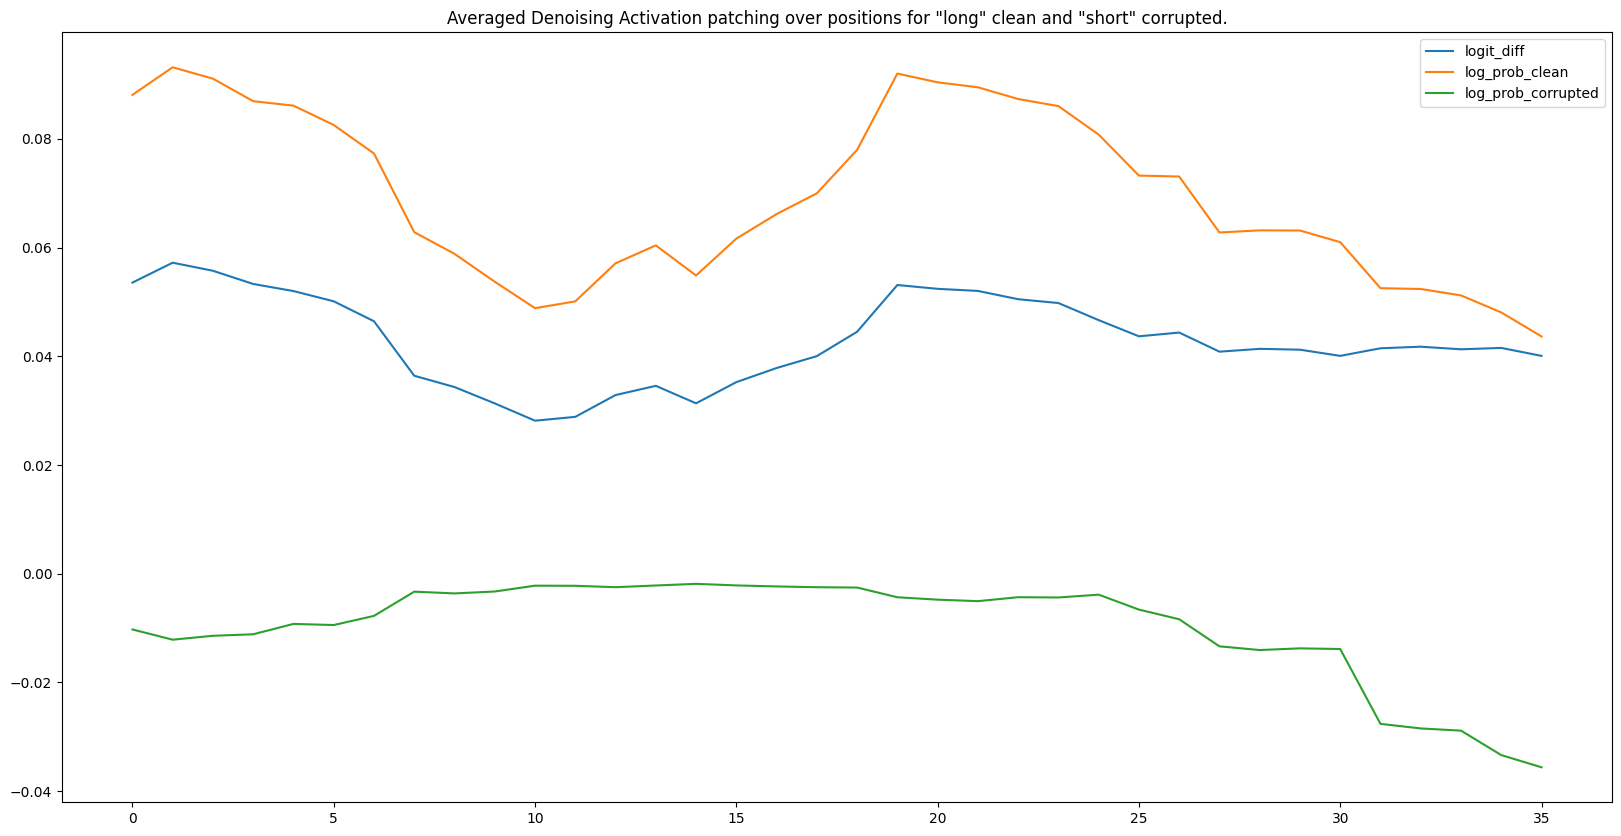

In [ ]:
for res in clean_long_res[:3]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged Denoising Activation patching over positions for \"long\" clean and \"short\" corrupted.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])


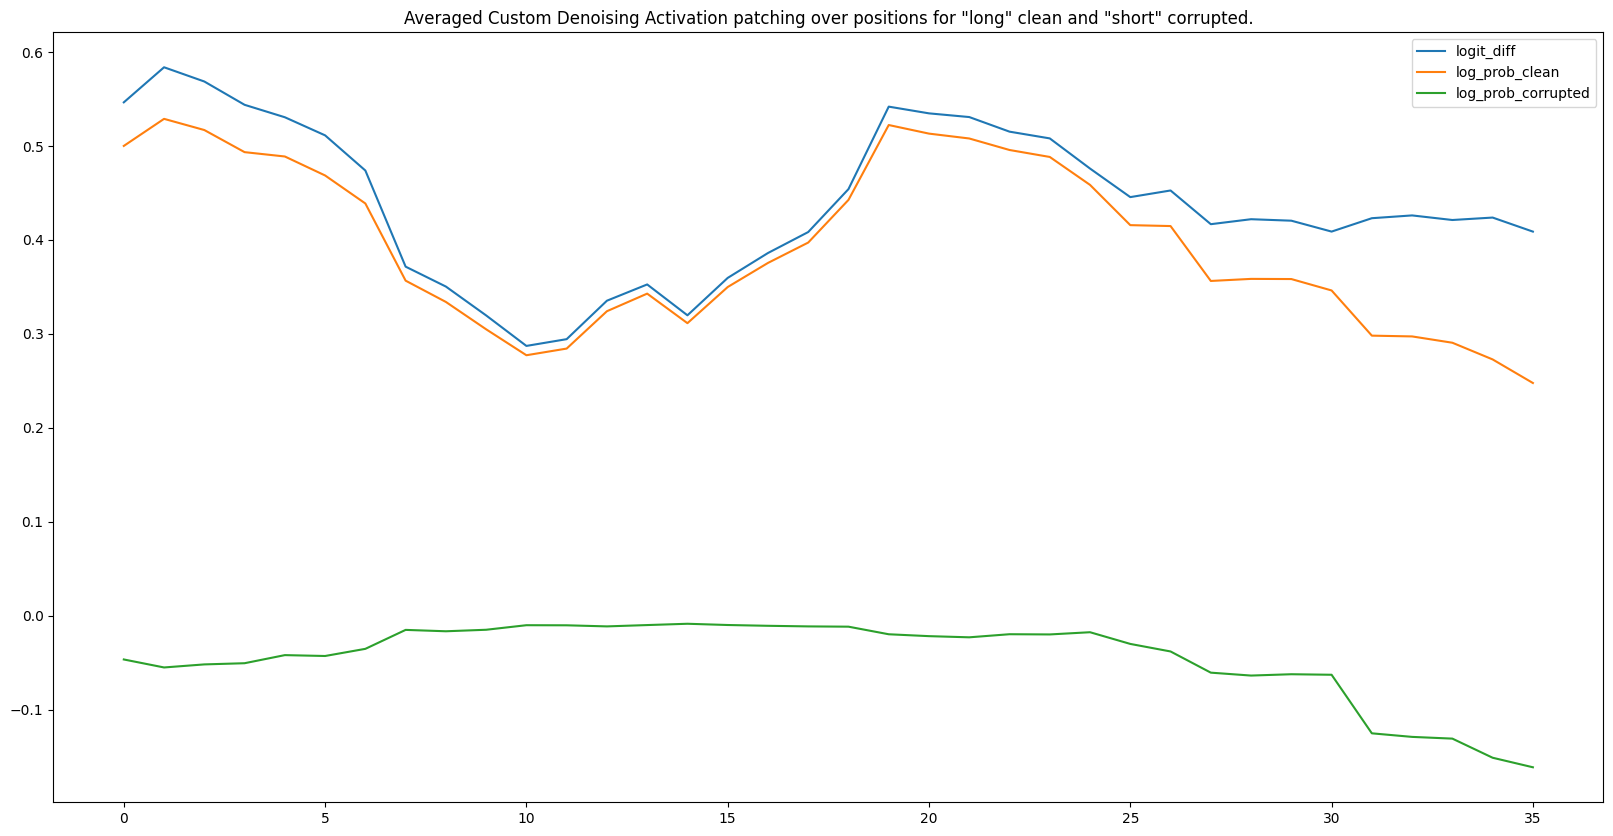

In [ ]:
for res in clean_long_res[3:6]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged Custom Denoising Activation patching over positions for \"long\" clean and \"short\" corrupted.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])


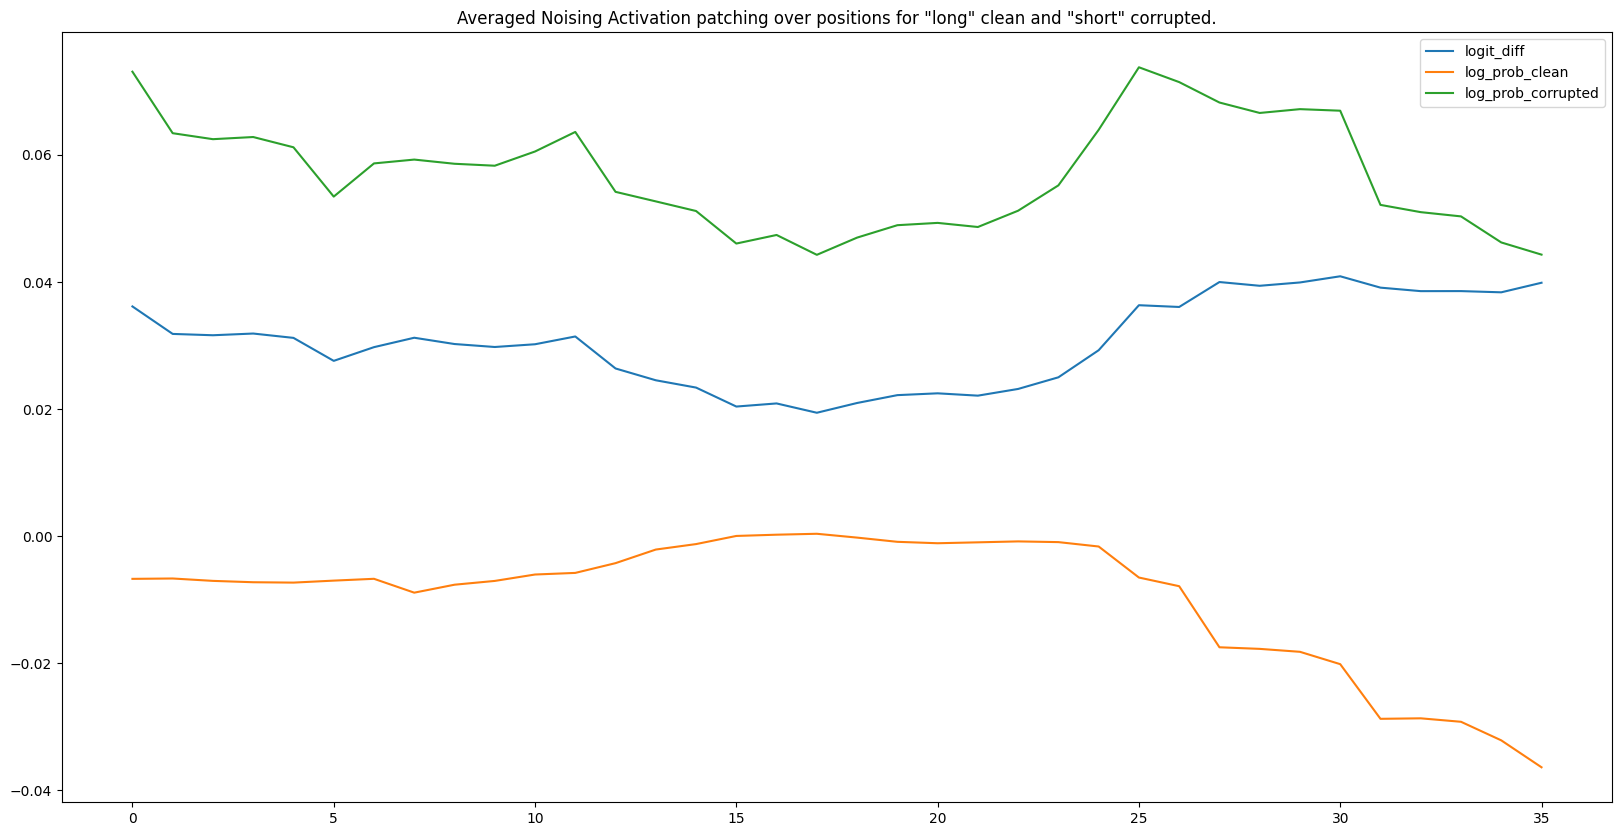

In [ ]:
for res in clean_long_res[6:9]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged Noising Activation patching over positions for \"long\" clean and \"short\" corrupted.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])

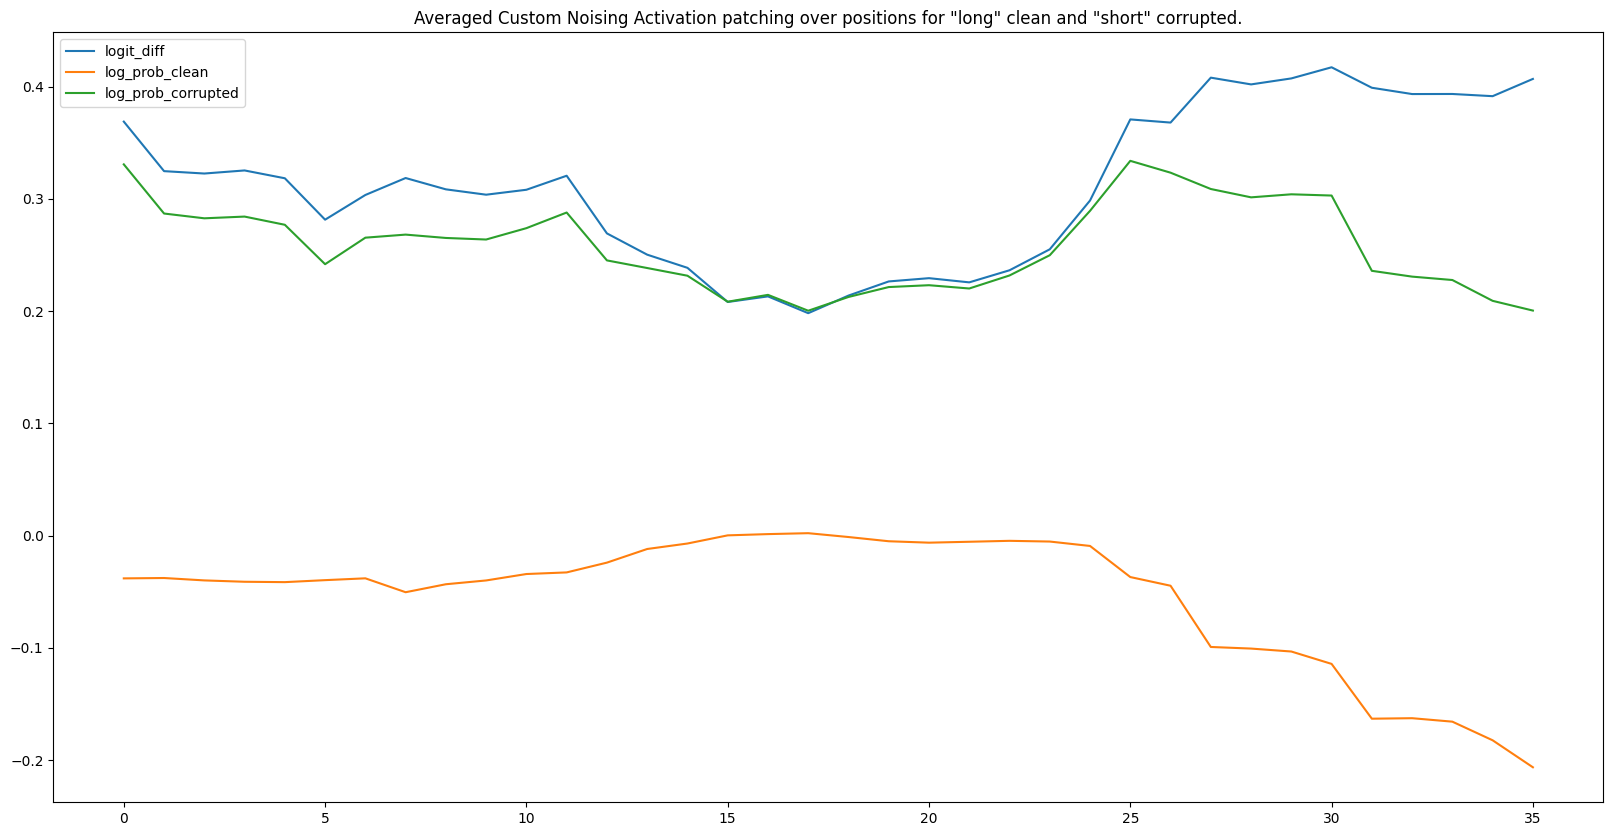

In [ ]:
for res in clean_long_res[9:12]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged Custom Noising Activation patching over positions for \"long\" clean and \"short\" corrupted.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])

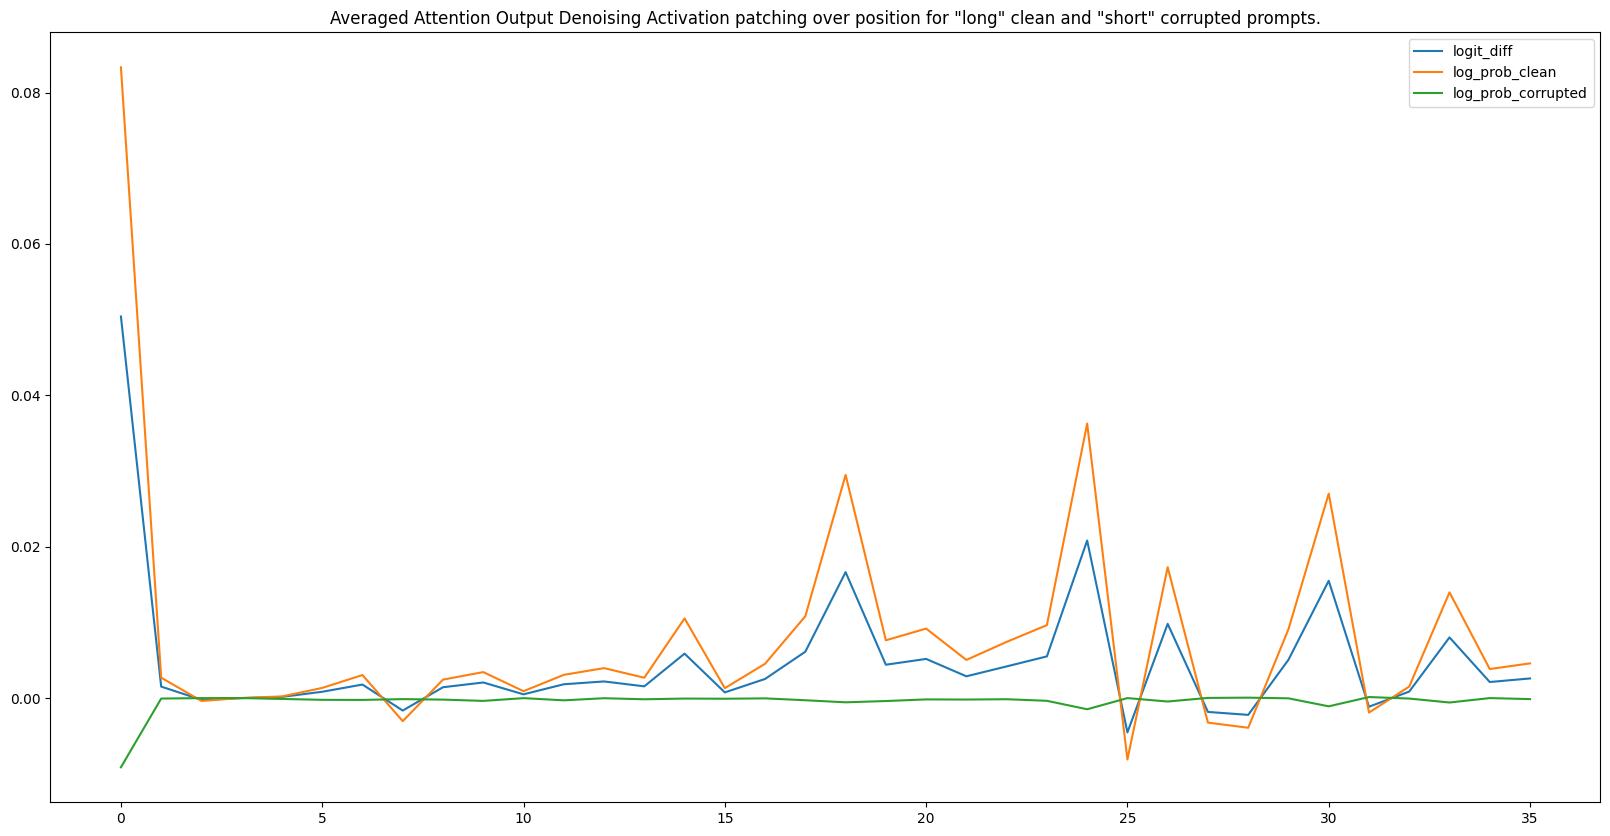

In [ ]:
for res in clean_long_attn[:3]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged Attention Output Denoising Activation patching over position for \"long\" clean and \"short\" corrupted prompts.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])

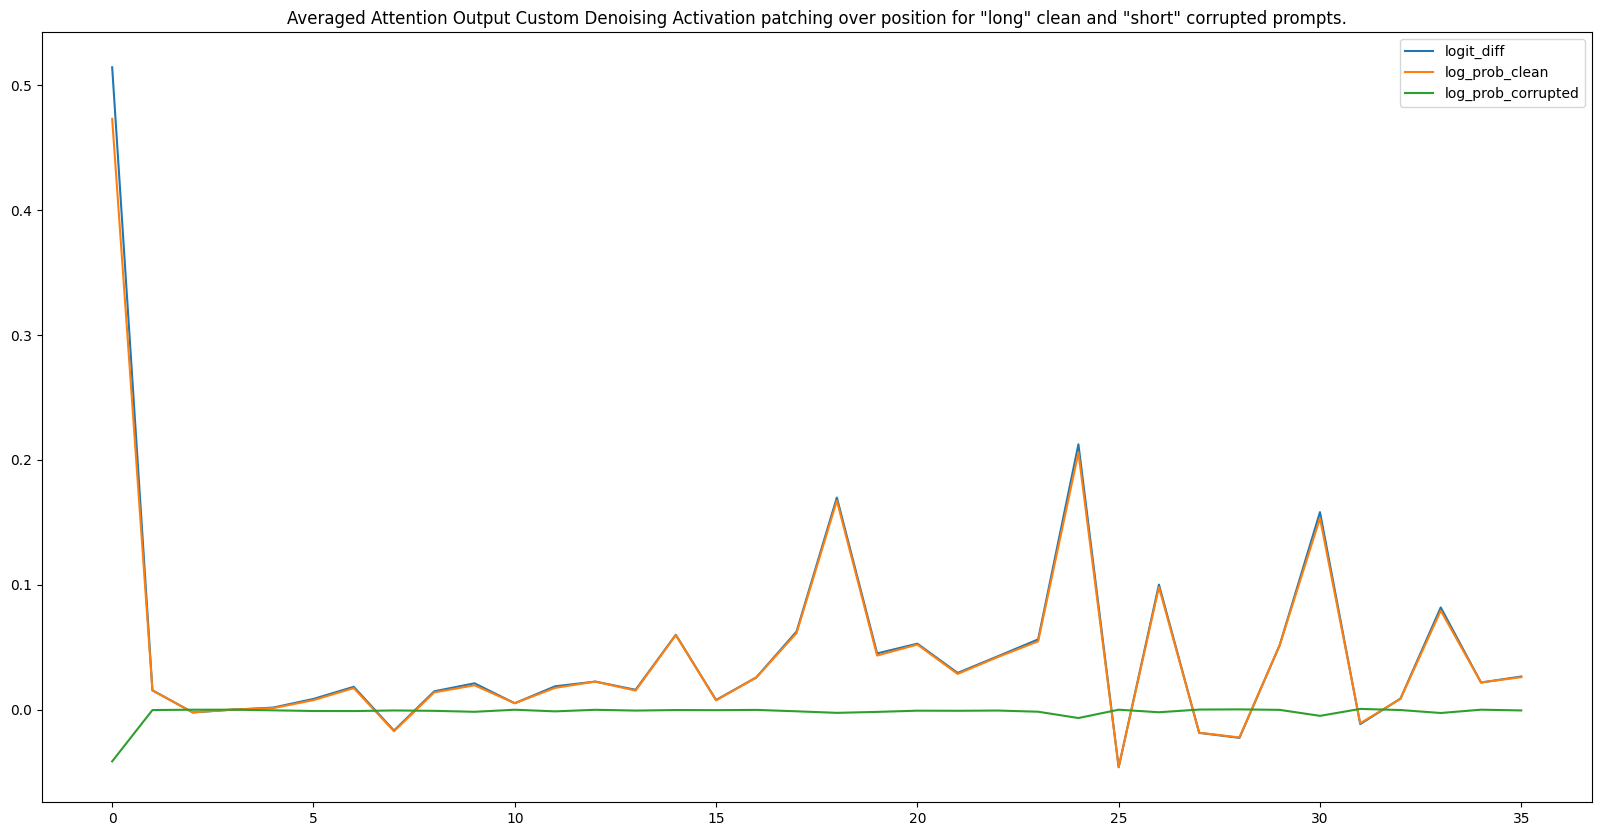

In [ ]:
for res in clean_long_attn[3:6]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged Attention Output Custom Denoising Activation patching over position for \"long\" clean and \"short\" corrupted prompts.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])

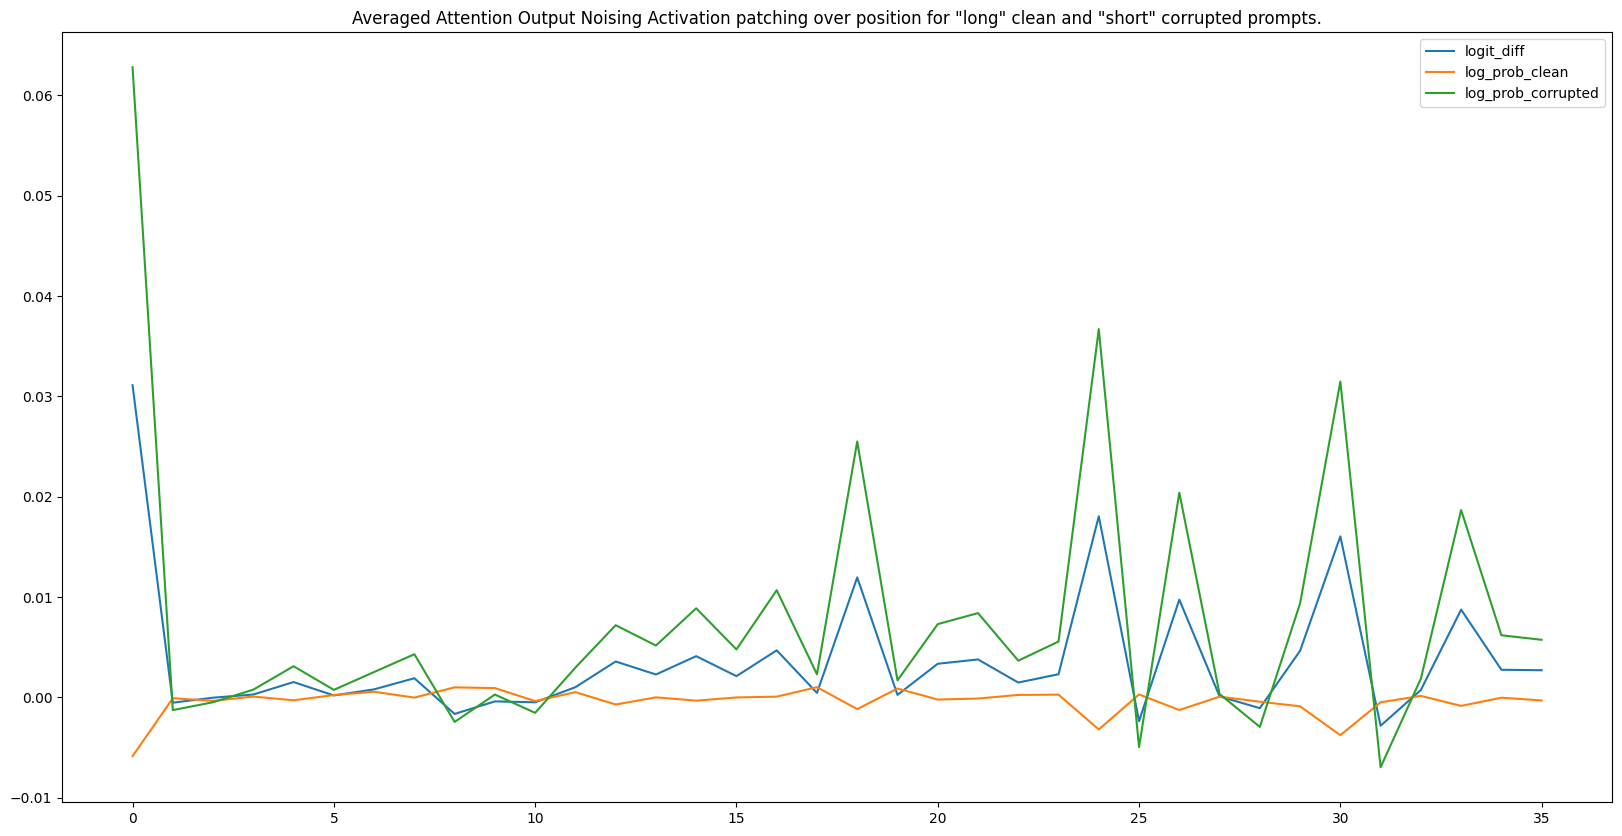

In [ ]:
for res in clean_long_attn[6:9]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged Attention Output Noising Activation patching over position for \"long\" clean and \"short\" corrupted prompts.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])

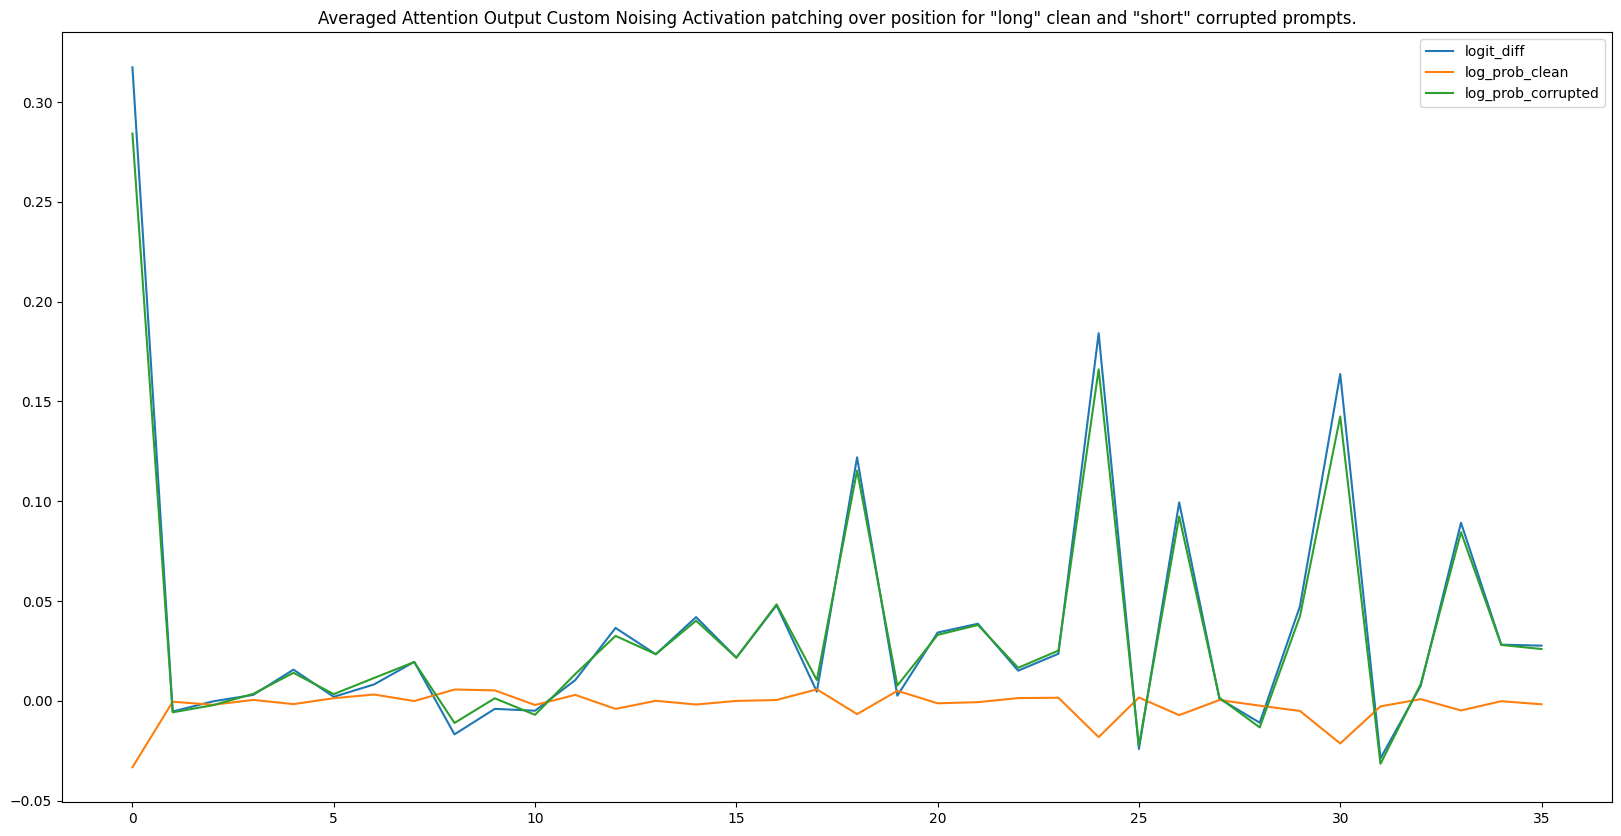

In [ ]:
for res in clean_long_attn[9:12]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged Attention Output Custom Noising Activation patching over position for \"long\" clean and \"short\" corrupted prompts.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])

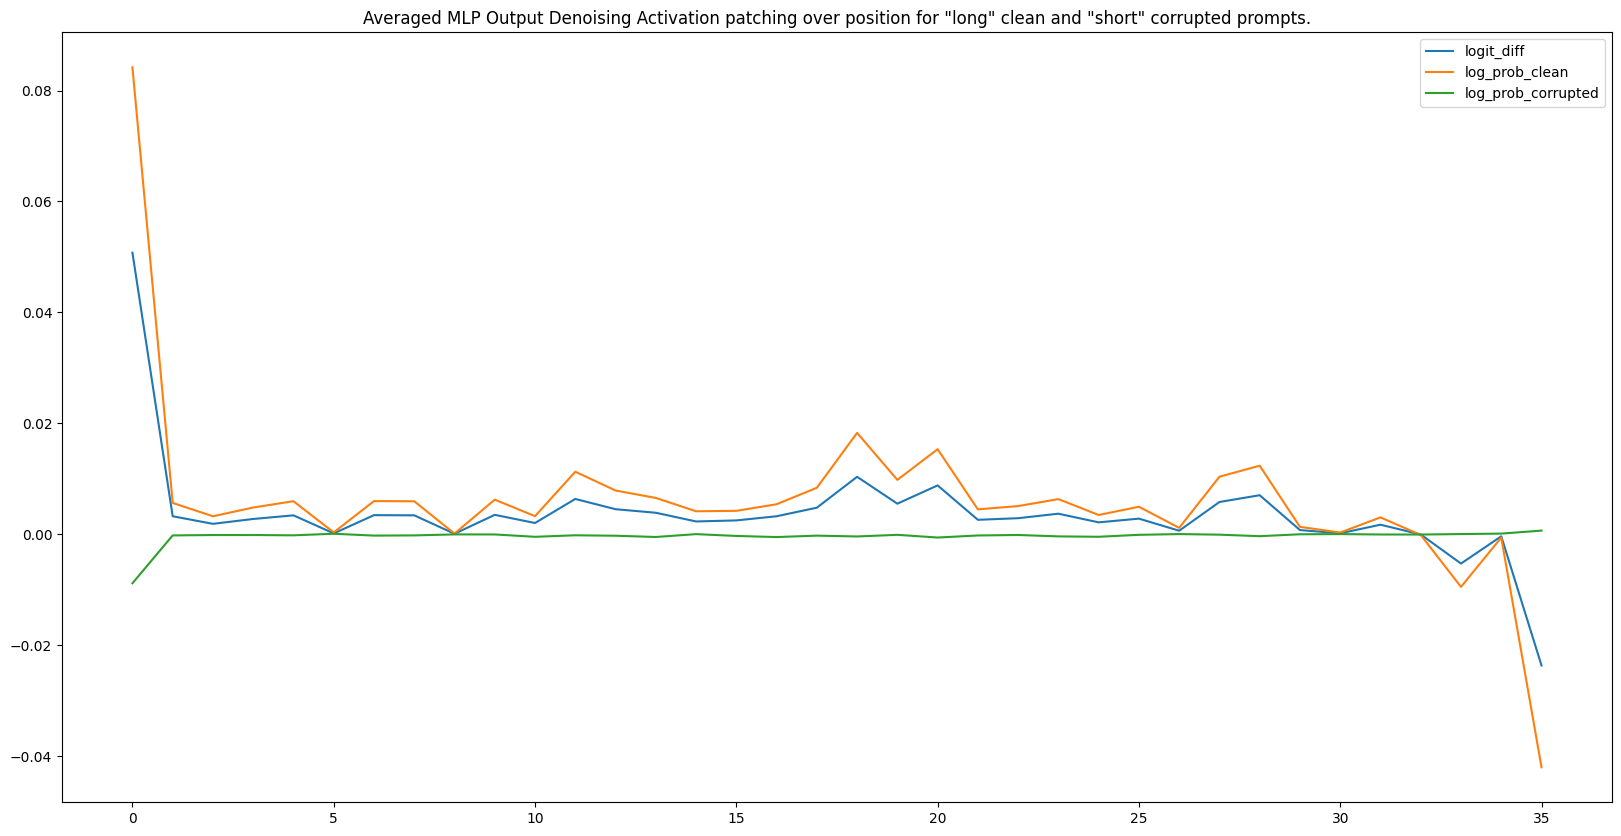

In [ ]:
for res in clean_long_mlp[:3]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged MLP Output Denoising Activation patching over position for \"long\" clean and \"short\" corrupted prompts.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])

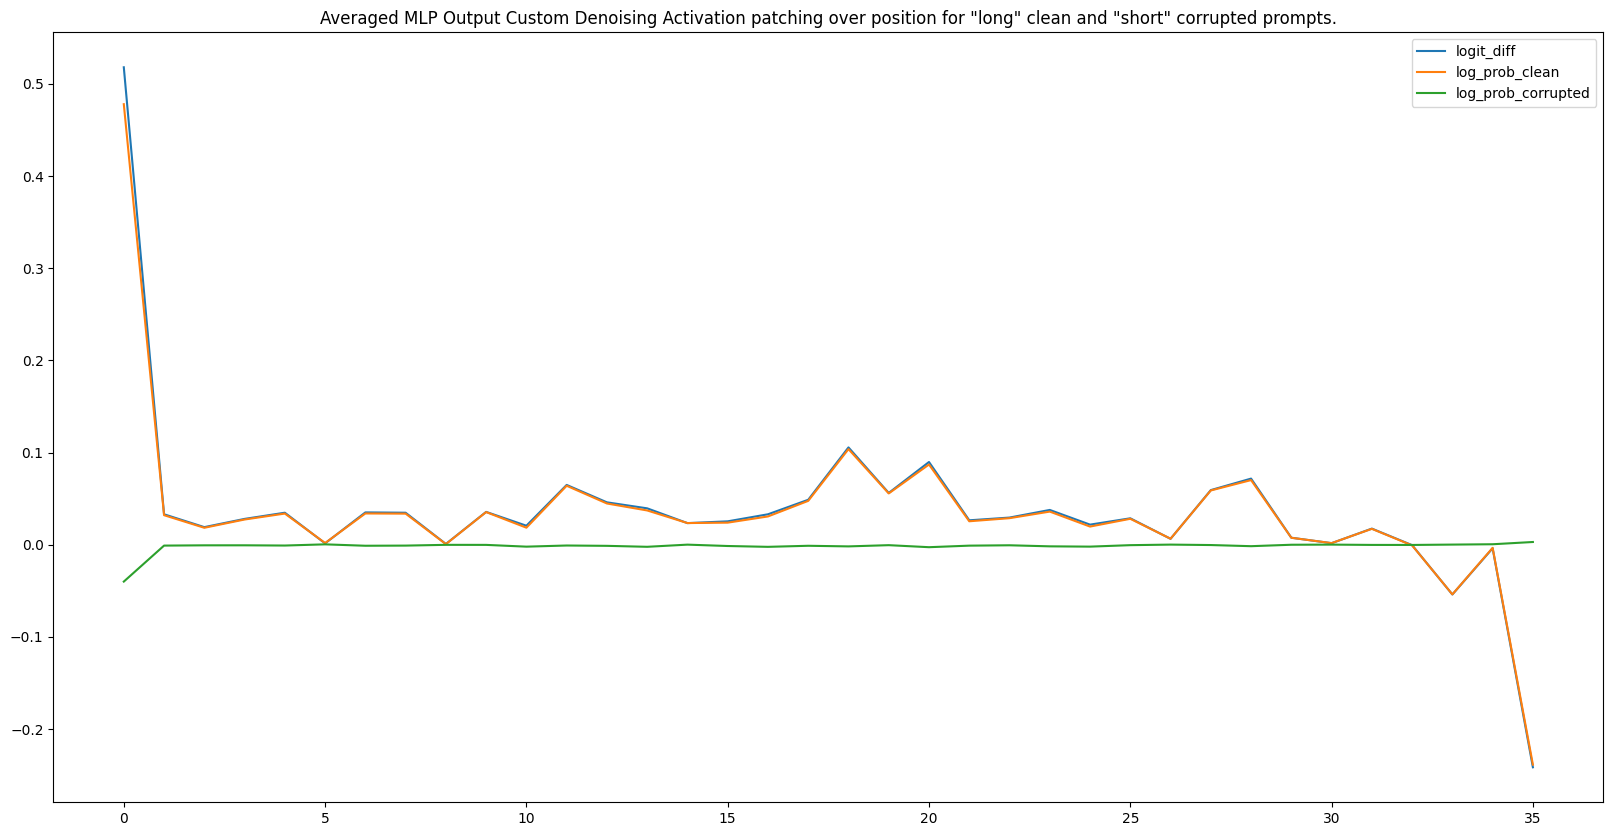

In [ ]:
for res in clean_long_mlp[3:6]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged MLP Output Custom Denoising Activation patching over position for \"long\" clean and \"short\" corrupted prompts.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])

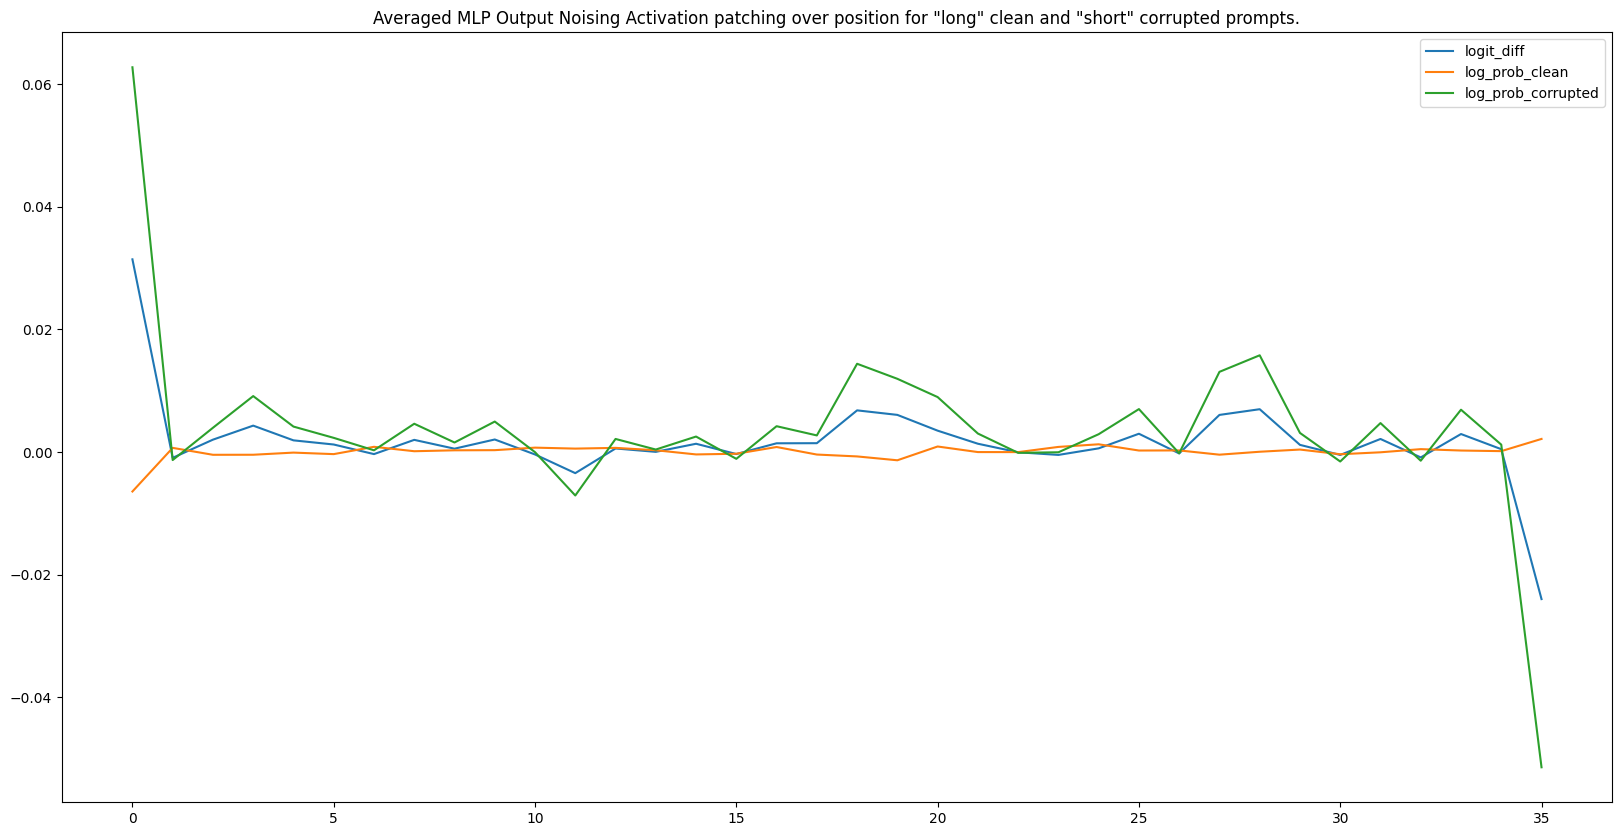

In [ ]:
for res in clean_long_mlp[6:9]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged MLP Output Noising Activation patching over position for \"long\" clean and \"short\" corrupted prompts.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])

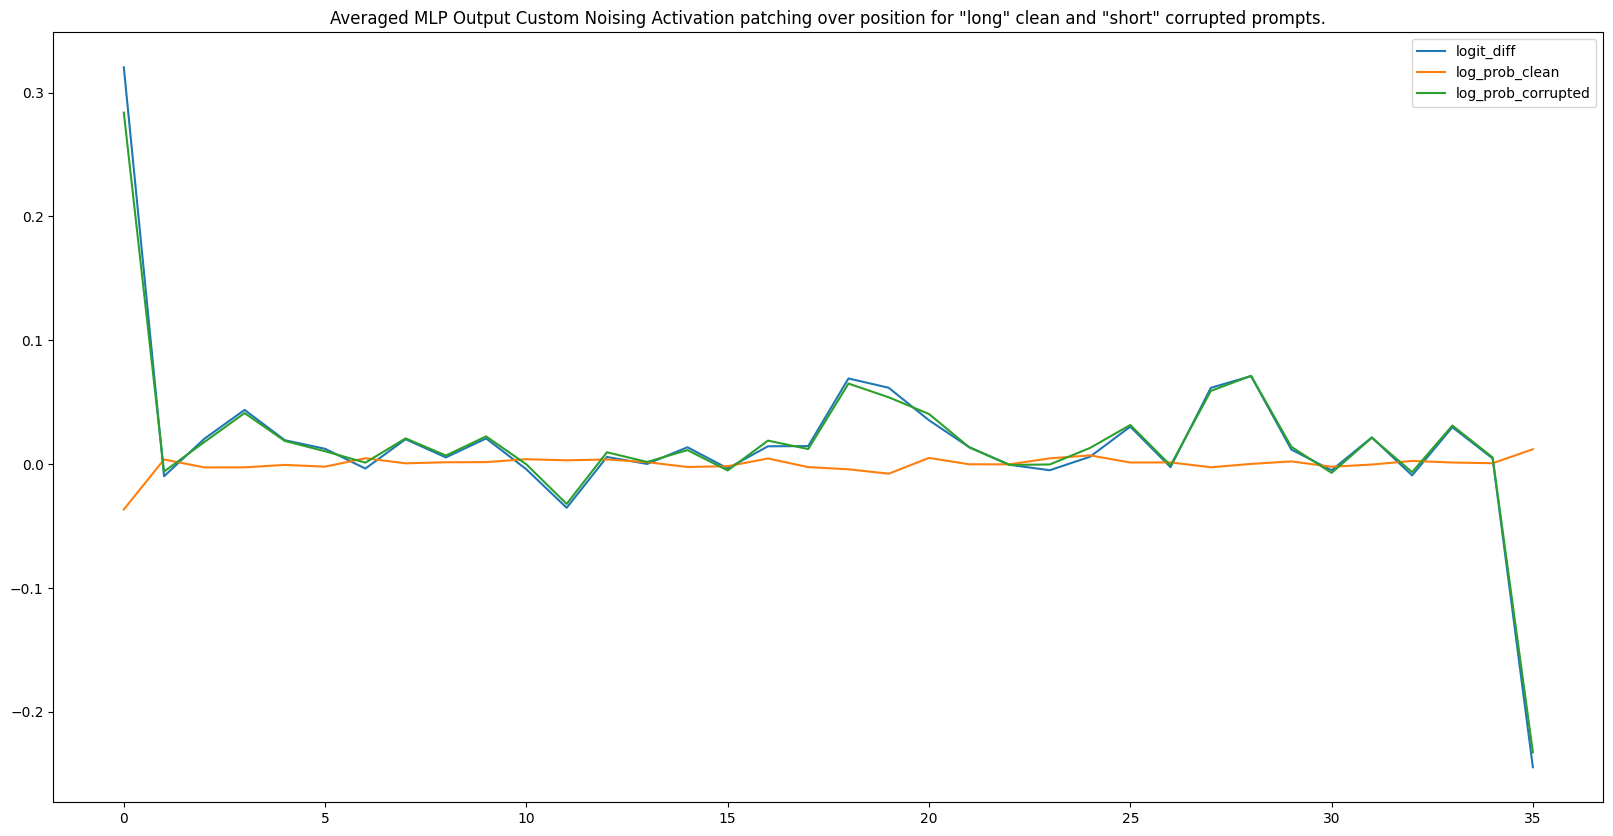

In [ ]:
for res in clean_long_mlp[9:12]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged MLP Output Custom Noising Activation patching over position for \"long\" clean and \"short\" corrupted prompts.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])